# 09 – Deployment / Inference

**Project:** Diabetes Prediction ML  
**Seminar:** Advanced Applied Data Science – Goethe University Frankfurt  
**Dataset:** CDC BRFSS 2015 – Diabetes Health Indicators (UCI #891)  
**Target:** `Diabetes_binary` (0 = No Diabetes, 1 = Prediabetes **or** Diabetes)  
**CRISP-DM phase:** 6 – Deployment · Scoring new data with the frozen final model

---

## Purpose

This notebook applies the **frozen final model from NB08** to data you provide. It does **not** retrain,
re-tune, or re-select anything — every decision (model, feature set, operating threshold, calibration)
was locked in NB07/NB08 and is loaded here from the saved artifacts. The notebook:

1. loads the deployable model and its model card from `models/`,
2. reads your data (in-memory DataFrame, a file, or — by default — the project test set),
3. validates that the columns and value ranges match what the model expects,
4. writes a probability and a 0/1 label for every row, and
5. **if** the data also contains a ground-truth label, evaluates the model on it at the frozen threshold.

The model needs the **21 raw BRFSS features**; the only engineered feature, `BMI_squared = BMI²`, is
computed inside this notebook, so no `src/` code or fitted preprocessing is required beyond the saved model.

## How to use (for the evaluator)

Pick **one** input in section 2:
- **In-memory DataFrame** — set `INPUT_DF` to a pandas DataFrame with the 21 raw feature columns.
- **Your own file** — set `INPUT_FILE` to a `.csv`, `.parquet`, or `.xlsx` (columns = the 21 raw features).
  A template with the right columns + example rows is written to `outputs/nb09/input_template.csv` to fill in.
- **Default (both `None`)** — runs on the project's held-out **test set** from `data/processed`, which
  **reproduces the NB08 test evaluation** end-to-end.

To **also evaluate**, include a `Diabetes_binary` column (0/1); the evaluation in section 6 then runs
automatically. Then **Run All** — predictions are written to `outputs/nb09/predictions.csv`.

> **Prerequisite:** NB08 must have been run once so that `models/nb08_final_lightgbm.joblib`,
> `models/nb08_final_lightgbm.txt`, and `models/nb08_model_card.json` exist. The default (test-set) run
> additionally needs `data/processed/X_test.parquet` + `y_test.parquet`; if those are absent it falls
> back to the template.

## 1. Setup — load the frozen model and its card

In [1]:
import warnings
warnings.simplefilter("ignore", category=FutureWarning)
warnings.simplefilter("ignore", category=UserWarning)

import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# light grid styling without a seaborn dependency (deployment = minimal extra imports)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

# Repo root: first parent folder containing notebooks/ (identical anchoring to NB03-08),
# so paths don't depend on the kernel's working directory.
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "notebooks").is_dir())
MODELS_DIR = PROJECT_ROOT / "models"
DATA_DIR   = PROJECT_ROOT / "data" / "processed"      # used only for the default test-set run
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "nb09"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- model card written by NB08: the single source of truth for serving ---
CARD_PATH = MODELS_DIR / "nb08_model_card.json"
assert CARD_PATH.exists(), (
    f"Model card not found at {CARD_PATH}.\n"
    "Run NB08 first - it writes models/nb08_model_card.json plus the model artifacts."
)
card = json.load(open(CARD_PATH))
EXPECTED_RAW = card["raw_features_expected"]       # the 21 raw inputs, in order
MODEL_INPUT  = card["model_input_columns"]         # exact column order the model expects (22)
THRESHOLD    = float(card["operating_threshold"])  # frozen recall-floor operating point
DERIVED      = card.get("derived_features", {})    # {"BMI_squared": "BMI ** 2"}

# --- fitted model: joblib pipeline first, native .txt booster as a version-robust fallback ---
# The native .txt fallback is numerically identical here because the final NB08 model is a *bare*
# LightGBM booster: its sklearn Pipeline contains NO scaler/transformer (LightGBM was trained
# directly on the numeric serving matrix in MODEL_INPUT order). So pipeline.predict_proba[:, 1]
# and booster.predict() agree exactly (verified by NB08's round-trip self-test). If a future model
# adds preprocessing to the pipeline, this fallback would no longer be equivalent.
import joblib, lightgbm
PIPE, BOOSTER = None, None
try:
    PIPE = joblib.load(MODELS_DIR / "nb08_final_lightgbm.joblib")
    ENGINE = "joblib pipeline"
except Exception as e:
    BOOSTER = lightgbm.Booster(model_file=str(MODELS_DIR / "nb08_final_lightgbm.txt"))
    ENGINE = f"native .txt booster (joblib load failed: {type(e).__name__})"

print(f"Model loaded via: {ENGINE}")
print(f"  primary model      : {card.get('model', '?')}")
print(f"  raw features (in)  : {len(EXPECTED_RAW)}")
print(f"  model input columns: {len(MODEL_INPUT)}  (raw + {list(DERIVED)})")
print(f"  operating threshold: {THRESHOLD:.4f}  ->  label = 1 if P(diabetes) >= {THRESHOLD:.4f}")
print(f"  outputs ->", OUTPUT_DIR.relative_to(PROJECT_ROOT))

Model loaded via: joblib pipeline
  primary model      : LightGBM
  raw features (in)  : 21
  model input columns: 22  (raw + ['BMI_squared'])
  operating threshold: 0.1379  ->  label = 1 if P(diabetes) >= 0.1379
  outputs -> outputs\nb09


## 2. Choose your input

Set **one** of `INPUT_DF` / `INPUT_FILE`, or leave both `None` to run on the project test set.

In [2]:
# ====================================================================
#  >>> CHOOSE YOUR INPUT (set ONE, or leave both None) <<<
#   INPUT_DF   : an in-memory pandas DataFrame with the 21 raw feature columns, or
#   INPUT_FILE : a path to .csv / .parquet / .xlsx with those columns, or
#   both None  : run on the project's held-out TEST SET (data/processed),
#                which reproduces the NB08 test evaluation.
#  Add an optional 'Diabetes_binary' column (0/1) to ALSO get an evaluation.
# ====================================================================
INPUT_DF   = None
INPUT_FILE = None     # e.g. PROJECT_ROOT / "data" / "external" / "my_cohort.csv"

def load_input(path):
    """Read .csv / .parquet / .xlsx into a DataFrame."""
    path = Path(path); ext = path.suffix.lower()
    if ext == ".csv":               return pd.read_csv(path)
    if ext in (".parquet", ".pq"):  return pd.read_parquet(path)
    if ext in (".xlsx", ".xls"):    return pd.read_excel(path)
    raise ValueError(f"Unsupported file type '{ext}'. Use .csv, .parquet or .xlsx.")

# Always (re)write a fill-in template so the expected schema is available for Option B.
TEMPLATE_PATH = OUTPUT_DIR / "input_template.csv"
pd.DataFrame([
    {"HighBP":1,"HighChol":1,"CholCheck":1,"Smoker":0,"Stroke":0,"HeartDiseaseorAttack":0,
     "PhysActivity":1,"Fruits":1,"Veggies":1,"HvyAlcoholConsump":0,"AnyHealthcare":1,
     "NoDocbcCost":0,"DiffWalk":0,"Sex":1,"GenHlth":3,"Age":9,"Education":5,"Income":6,
     "MentHlth":2,"PhysHlth":0,"BMI":29.0},
    {"HighBP":0,"HighChol":0,"CholCheck":1,"Smoker":0,"Stroke":0,"HeartDiseaseorAttack":0,
     "PhysActivity":1,"Fruits":1,"Veggies":1,"HvyAlcoholConsump":0,"AnyHealthcare":1,
     "NoDocbcCost":0,"DiffWalk":0,"Sex":0,"GenHlth":2,"Age":4,"Education":6,"Income":8,
     "MentHlth":0,"PhysHlth":0,"BMI":22.5},
    {"HighBP":1,"HighChol":1,"CholCheck":1,"Smoker":1,"Stroke":0,"HeartDiseaseorAttack":1,
     "PhysActivity":0,"Fruits":0,"Veggies":0,"HvyAlcoholConsump":0,"AnyHealthcare":1,
     "NoDocbcCost":1,"DiffWalk":1,"Sex":1,"GenHlth":5,"Age":12,"Education":3,"Income":2,
     "MentHlth":15,"PhysHlth":20,"BMI":41.0},
])[EXPECTED_RAW].to_csv(TEMPLATE_PATH, index=False)

# Resolve the data source (priority: in-memory DataFrame > file > test set > template fallback).
if INPUT_DF is not None:
    raw_df = INPUT_DF.copy()
    SOURCE = "in-memory DataFrame (INPUT_DF)"
elif INPUT_FILE is not None:
    raw_df = load_input(Path(INPUT_FILE))
    SOURCE = f"file: {Path(INPUT_FILE).name}"
else:
    xtp, ytp = DATA_DIR / "X_test.parquet", DATA_DIR / "y_test.parquet"
    if xtp.exists() and ytp.exists():
        Xte = pd.read_parquet(xtp)[EXPECTED_RAW]
        yte = pd.read_parquet(ytp).squeeze("columns")
        raw_df = Xte.copy()
        raw_df["Diabetes_binary"] = yte.values
        SOURCE = "project TEST SET (data/processed) -> reproduces the NB08 test evaluation"
    else:
        raw_df = pd.read_csv(TEMPLATE_PATH)
        SOURCE = "template smoke test (test set not found under data/processed)"

print(f"Template (schema) written: {TEMPLATE_PATH.relative_to(PROJECT_ROOT)}  ({len(EXPECTED_RAW)} columns)")
print(f"Input source : {SOURCE}")
print(f"Rows loaded  : {len(raw_df):,}")

Template (schema) written: outputs\nb09\input_template.csv  (21 columns)
Input source : project TEST SET (data/processed) -> reproduces the NB08 test evaluation
Rows loaded  : 50,737


## 3. Validate the input

Missing required columns are a hard error (with the list of what's missing). Everything else — extra columns, out-of-range values, missing values — is reported as a **warning** and never blocks scoring. Note that warnings do not block scoring, but outputs for rows with **severe coding deviations** should not be interpreted as valid BRFSS-like predictions.

In [3]:
# accepted names for an optional ground-truth label column (enables section 6)
LABEL_ALIASES = ["Diabetes_binary", "Diabetes_012", "Diabetes", "diabetes", "target", "label", "y"]

# expected value ranges (mirror the NB03 BRFSS feature definitions) -- VALIDATION WARNINGS ONLY;
# they never alter the data or block scoring.
BINARY_SET = {"HighBP","HighChol","CholCheck","Smoker","Stroke","HeartDiseaseorAttack",
              "PhysActivity","Fruits","Veggies","HvyAlcoholConsump","AnyHealthcare",
              "NoDocbcCost","DiffWalk","Sex"}
RANGES = {"GenHlth":(1,5), "Age":(1,13), "Education":(1,6), "Income":(1,8),
          "MentHlth":(0,30), "PhysHlth":(0,30), "BMI":(10,100)}

def validate(df):
    """Hard-fail on missing required columns; everything else -> warnings."""
    msgs = []
    missing = [c for c in EXPECTED_RAW if c not in df.columns]
    assert not missing, (
        f"Input is missing {len(missing)} required column(s): {missing}\n"
        f"The model needs exactly these 21 raw features:\n  {EXPECTED_RAW}"
    )
    label_col = next((c for c in LABEL_ALIASES if c in df.columns), None)
    has_label = label_col is not None
    extras = [c for c in df.columns if c not in EXPECTED_RAW and c != label_col]
    if extras:
        msgs.append(f"{len(extras)} extra column(s) ignored: {extras}")
    for c in EXPECTED_RAW:
        s = pd.to_numeric(df[c], errors="coerce")
        n_nan = int(s.isna().sum())
        if n_nan:
            msgs.append(f"'{c}': {n_nan} missing/non-numeric value(s) "
                        "(LightGBM handles missing values natively)")
        if c in BINARY_SET:
            bad = set(pd.unique(s.dropna())) - {0, 1, 0.0, 1.0}
            if bad:
                msgs.append(f"'{c}': expected 0/1 but also saw {sorted(bad)[:5]}")
        elif c in RANGES and s.dropna().size:
            lo, hi = RANGES[c]
            if s.min() < lo or s.max() > hi:
                msgs.append(f"'{c}': range [{s.min()}, {s.max()}] outside expected [{lo}, {hi}]")
    return has_label, label_col, msgs

HAS_LABEL, LABEL_COL, VAL_WARNINGS = validate(raw_df)

print("All 21 required columns present : yes")
print("Ground-truth label present      : "
      + (f"yes (column '{LABEL_COL}') -> evaluation WILL run" if HAS_LABEL
         else "no -> evaluation SKIPPED (predictions only)"))
if VAL_WARNINGS:
    print(f"\n{len(VAL_WARNINGS)} validation warning(s):")
    for w in VAL_WARNINGS:
        print("  !", w)
else:
    print("No validation warnings.")

All 21 required columns present : yes
Ground-truth label present      : yes (column 'Diabetes_binary') -> evaluation WILL run
No validation warnings.


## 4. Predict

In [4]:
def score(df_raw):
    """Raw 21 features -> P(diabetes). Recomputes the derived column(s) from the raw inputs
    (so they're always consistent with training), enforces the exact training column order,
    then uses whichever engine loaded in Setup."""
    X = df_raw.copy()
    for name in DERIVED:                 # the project's only serving-time feature is BMI_squared
        if name == "BMI_squared":
            X["BMI_squared"] = X["BMI"] ** 2
        # extend here if a future model adds other engineered serving features
    X = X[MODEL_INPUT]                   # exact order the model was trained on
    if PIPE is not None:
        return PIPE.predict_proba(X)[:, 1]
    return BOOSTER.predict(X.values)

proba = score(raw_df)
label = (proba >= THRESHOLD).astype(int)

predictions = raw_df.copy()
predictions["diabetes_proba"] = np.round(proba, 6)
predictions["diabetes_pred"]  = label
PRED_PATH = OUTPUT_DIR / "predictions.csv"
predictions.to_csv(PRED_PATH, index=False)

print(f"Scored {len(proba):,} row(s) at threshold {THRESHOLD:.4f}")
print(f"  predicted positive (prediabetes or diabetes): {int(label.sum()):,}  ({label.mean()*100:.1f}%)")
print(f"  probability  min / median / max             : "
      f"{proba.min():.3f} / {np.median(proba):.3f} / {proba.max():.3f}")
print(f"  saved ->", PRED_PATH.relative_to(PROJECT_ROOT))

Scored 50,737 row(s) at threshold 0.1379
  predicted positive (prediabetes or diabetes): 18,256  (36.0%)
  probability  min / median / max             : 0.000 / 0.077 / 0.874
  saved -> outputs\nb09\predictions.csv


## 5. Prediction preview

    diabetes_proba  diabetes_pred  Diabetes_binary  BMI  GenHlth  Age  HighBP
5         0.111472              0                0   25        2   10       1
9         0.032566              0                0   24        2    8       0
10        0.110875              0                1   25        3   13       0
12        0.043490              0                0   26        3    7       0
14        0.200841              1                0   33        4    4       0
15        0.047542              0                0   33        2    6       1
34        0.131067              0                1   24        2   12       1
36        0.193289              1                0   24        3    8       1
48        0.560176              1                0   37        3   10       1
49        0.471678              1                1   33        3   11       1


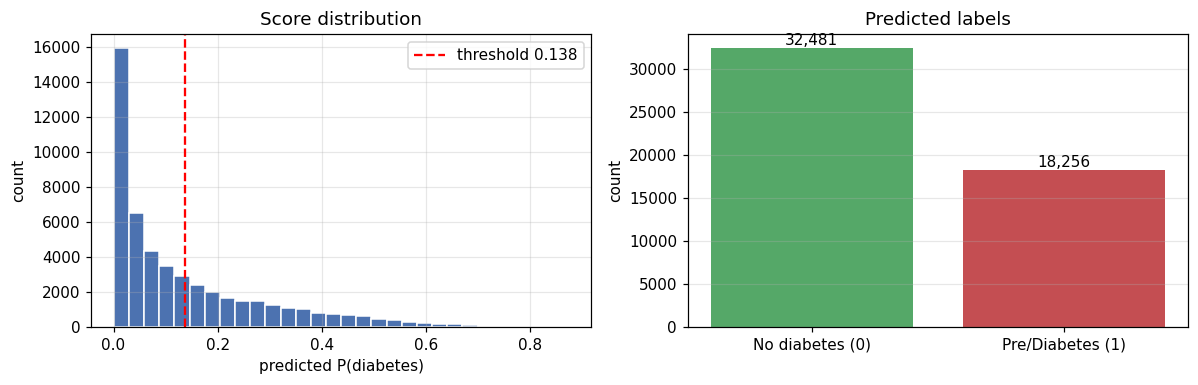

In [5]:
# first rows + score distribution
show_cols = (["diabetes_proba", "diabetes_pred"] + ([LABEL_COL] if HAS_LABEL else [])
             + ["BMI", "GenHlth", "Age", "HighBP"])
print(predictions[show_cols].head(10).to_string(index=True))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(proba, bins=min(30, max(5, len(proba))), color="#4C72B0", edgecolor="white")
ax[0].axvline(THRESHOLD, ls="--", c="red", lw=1.5, label=f"threshold {THRESHOLD:.3f}")
ax[0].set_xlabel("predicted P(diabetes)"); ax[0].set_ylabel("count")
ax[0].set_title("Score distribution"); ax[0].legend()

counts = pd.Series(label).value_counts().reindex([0, 1], fill_value=0)
ax[1].bar(["No diabetes (0)", "Pre/Diabetes (1)"], counts.values, color=["#55A868", "#C44E52"])
ax[1].set_title("Predicted labels"); ax[1].set_ylabel("count"); ax[1].grid(axis="x")
for i, v in enumerate(counts.values):
    ax[1].text(i, v, f"{int(v):,}", ha="center", va="bottom")
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "nb09_score_distribution.png", bbox_inches="tight"); plt.show()

## 6. Evaluation — *runs only if a label column is present*

Reports the same metrics as NB08, but on **your** data and at the **frozen** operating point — nothing is re-tuned to your data, so it is an honest out-of-the-box generalisation check. Invalid labels (missing / non-numeric) are dropped **for evaluation only**; their predictions are kept.

=== Evaluation on YOUR data at the frozen NB08 threshold ===
{
  "n": 50737,
  "prevalence": 0.1393,
  "threshold": 0.1379,
  "precision": 0.3057,
  "recall_sensitivity": 0.7894,
  "specificity": 0.7097,
  "F1": 0.4407,
  "F2": 0.5996,
  "balanced_acc": 0.7496,
  "MCC": 0.3601,
  "confusion": {
    "TN": 30992,
    "FP": 12675,
    "FN": 1489,
    "TP": 5581
  },
  "PR_AUC": 0.433,
  "ROC_AUC": 0.8288,
  "Brier": 0.0968,
  "PR_AUC_lift_over_prevalence": 3.11
}

                  precision    recall  f1-score   support

 No diabetes (0)      0.954     0.710     0.814     43667
Pre/Diabetes (1)      0.306     0.789     0.441      7070

        accuracy                          0.721     50737
       macro avg      0.630     0.750     0.627     50737
    weighted avg      0.864     0.721     0.762     50737



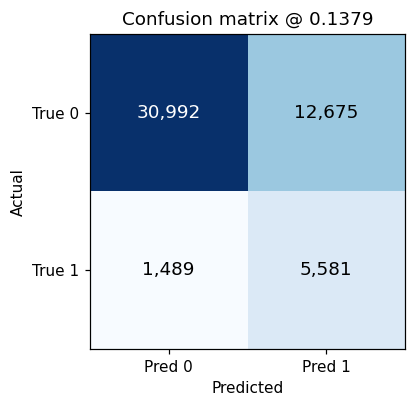

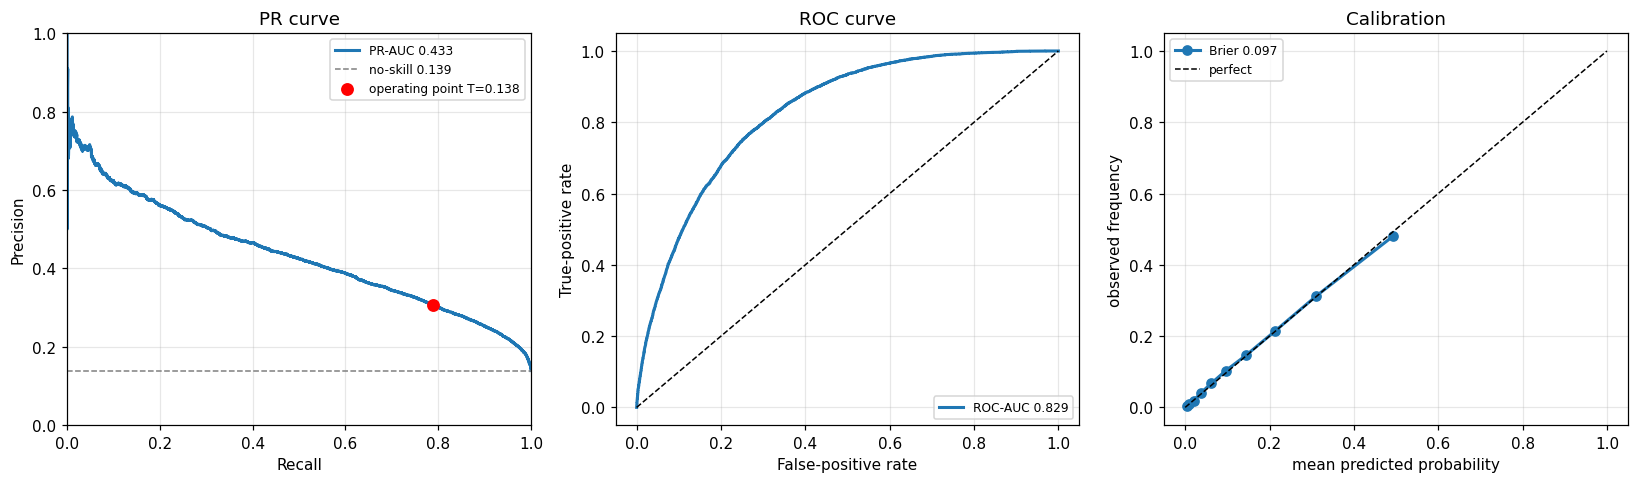

In [6]:
if not HAS_LABEL:
    print("No ground-truth label column found -> evaluation skipped.")
    print("Add a 'Diabetes_binary' column (0/1) to the input to enable metrics.")
else:
    from sklearn.metrics import (average_precision_score, roc_auc_score, brier_score_loss,
                                 precision_score, recall_score, f1_score, fbeta_score,
                                 confusion_matrix, matthews_corrcoef, balanced_accuracy_score,
                                 classification_report, precision_recall_curve, roc_curve)
    from sklearn.calibration import calibration_curve

    # --- robust label handling: coerce -> (binarise Diabetes_012) -> drop invalid for EVAL ONLY ---
    y_series = pd.to_numeric(raw_df[LABEL_COL], errors="coerce")
    valid    = y_series.notna()
    n_drop   = int((~valid).sum())
    if n_drop:
        print(f"! Dropping {n_drop} row(s) with missing/non-numeric labels "
              "(evaluation only; predictions for those rows are kept).")
    y_valid = y_series[valid]
    if LABEL_COL == "Diabetes_012":
        # 0=no, 1=prediabetes, 2=diabetes -> positive = prediabetes OR diabetes (matches the model target)
        y_valid = (y_valid > 0).astype(int)
        print("Note: 'Diabetes_012' binarised as (>0) -> 1 (prediabetes or diabetes), matching the model target.")
    y_true     = y_valid.astype(int).values
    proba_eval = proba[valid.values]
    pred_eval  = label[valid.values]

    assert set(np.unique(y_true)).issubset({0, 1}), (
        f"Label must be binary 0/1 after processing, got classes {sorted(set(np.unique(y_true)))}.\n"
        "If your column uses 0/1/2 (no/pre/diabetes), name it 'Diabetes_012' so it is binarised, "
        "or binarise it yourself before loading."
    )

    if len(y_true) == 0:
        print("No valid labels remain after cleaning -> evaluation skipped.")
    else:
        prevalence   = float(y_true.mean())
        both_classes = len(np.unique(y_true)) == 2
        tn, fp, fn, tp = confusion_matrix(y_true, pred_eval, labels=[0, 1]).ravel()

        metrics = {
            "n": int(len(y_true)), "prevalence": round(prevalence, 4), "threshold": round(THRESHOLD, 4),
            "precision":          round(precision_score(y_true, pred_eval, zero_division=0), 4),
            "recall_sensitivity": round(recall_score(y_true, pred_eval, zero_division=0), 4),
            "specificity":        round(tn / (tn + fp), 4) if (tn + fp) else None,
            "F1":                 round(f1_score(y_true, pred_eval, zero_division=0), 4),
            "F2":                 round(fbeta_score(y_true, pred_eval, beta=2.0, zero_division=0), 4),
            "balanced_acc":       round(balanced_accuracy_score(y_true, pred_eval), 4),
            "MCC":                round(matthews_corrcoef(y_true, pred_eval), 4),
            "confusion": {"TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp)},
        }
        if both_classes:
            metrics["PR_AUC"]  = round(average_precision_score(y_true, proba_eval), 4)
            metrics["ROC_AUC"] = round(roc_auc_score(y_true, proba_eval), 4)
            metrics["Brier"]   = round(brier_score_loss(y_true, proba_eval), 4)
            metrics["PR_AUC_lift_over_prevalence"] = round(metrics["PR_AUC"] / prevalence, 2) if prevalence else None
        else:
            print("! Only one class present in the labels -> AUC / Brier undefined; "
                  "showing threshold metrics + confusion matrix only.\n")

        print("=== Evaluation on YOUR data at the frozen NB08 threshold ===")
        print(json.dumps(metrics, indent=2))
        print()
        print(classification_report(y_true, pred_eval, labels=[0, 1],
                                    target_names=["No diabetes (0)", "Pre/Diabetes (1)"],
                                    digits=3, zero_division=0))
        json.dump(metrics, open(OUTPUT_DIR / "nb09_evaluation.json", "w"), indent=2)

        # --- confusion matrix (pure matplotlib, no seaborn) ---
        cm = confusion_matrix(y_true, pred_eval, labels=[0, 1])
        fig, ax = plt.subplots(figsize=(4.4, 3.8))
        ax.imshow(cm, cmap="Blues"); ax.grid(False)
        ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred 0", "Pred 1"])
        ax.set_yticks([0, 1]); ax.set_yticklabels(["True 0", "True 1"])
        thr_c = cm.max() / 2 if cm.max() else 0
        for (r, c), v in np.ndenumerate(cm):
            ax.text(c, r, f"{v:,}", ha="center", va="center",
                    color="white" if v > thr_c else "black", fontsize=12)
        ax.set_title(f"Confusion matrix @ {THRESHOLD:.4f}"); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
        plt.tight_layout(); plt.savefig(OUTPUT_DIR / "nb09_confusion_matrix.png", bbox_inches="tight"); plt.show()

        # --- PR / ROC / calibration (only meaningful with both classes and enough rows) ---
        if both_classes:
            try:
                fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
                p_, r_, _ = precision_recall_curve(y_true, proba_eval)
                ax[0].plot(r_, p_, lw=2, label=f"PR-AUC {metrics['PR_AUC']:.3f}")
                ax[0].axhline(prevalence, ls="--", c="grey", lw=1, label=f"no-skill {prevalence:.3f}")
                ax[0].scatter([metrics["recall_sensitivity"]], [metrics["precision"]], c="red", s=55, zorder=5,
                              label=f"operating point T={THRESHOLD:.3f}")
                ax[0].set_xlabel("Recall"); ax[0].set_ylabel("Precision"); ax[0].set_xlim(0, 1); ax[0].set_ylim(0, 1)
                ax[0].set_title("PR curve"); ax[0].legend(loc="upper right", fontsize=8)
                fpr, tpr, _ = roc_curve(y_true, proba_eval)
                ax[1].plot(fpr, tpr, lw=2, label=f"ROC-AUC {metrics['ROC_AUC']:.3f}")
                ax[1].plot([0, 1], [0, 1], "k--", lw=1)
                ax[1].set_xlabel("False-positive rate"); ax[1].set_ylabel("True-positive rate")
                ax[1].set_title("ROC curve"); ax[1].legend(loc="lower right", fontsize=8)
                nbins = min(10, max(2, len(y_true) // 20))
                frac_pos, mean_pred = calibration_curve(y_true, proba_eval, n_bins=nbins, strategy="quantile")
                ax[2].plot(mean_pred, frac_pos, "o-", lw=2, label=f"Brier {metrics['Brier']:.3f}")
                ax[2].plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
                ax[2].set_xlabel("mean predicted probability"); ax[2].set_ylabel("observed frequency")
                ax[2].set_title("Calibration"); ax[2].legend(loc="upper left", fontsize=8)
                plt.tight_layout(); plt.savefig(OUTPUT_DIR / "nb09_diagnostics.png", bbox_inches="tight"); plt.show()
            except Exception as e:
                print(f"(diagnostic curves skipped: {type(e).__name__} - likely too few rows)")

## 7. Summary & notes

- **What you get.** A probability `diabetes_proba` and a binary `diabetes_pred` per row, written to
  `outputs/nb09/predictions.csv`. The label uses the **frozen operating threshold** (recall-floor policy
  from NB07: the largest OOF threshold with recall ≥ 0.80), *not* the default 0.5 — the project optimises
  for *catching* cases (sensitivity), accepting more false positives in return.
- **Default run = the test set.** With no input set, the notebook scores the held-out NB03 test set and
  **reproduces the NB08 headline metrics**, which doubles as an end-to-end sanity check of the pipeline.
- **Probabilities are raw / uncalibrated** (calibration was decided as "none" in NB07). Treat
  `diabetes_proba` as a **ranking / screening score**, not a precise probability.
- **Evaluation** (section 6) reports the same metrics as NB08 — PR-AUC, ROC-AUC, Brier, and
  precision/recall/F1/F2/MCC at the threshold — on *your* data, at the *frozen* operating point.
- **Caveats.** Predictions are only as valid as the input: values should follow the BRFSS coding from
  NB03. Validation warnings flag deviations; rows with severe coding deviations should not be read as
  valid BRFSS-like predictions. Labels are diagnosis-based, so some "false positives" may be genuinely
  high-risk / undiagnosed profiles (see NB08 §11).

## References

- CDC BRFSS 2015 — Diabetes Health Indicators, UCI Machine Learning Repository #891.
- Frozen model, operating threshold, and reference metrics: NB07 (tuning) and NB08 (evaluation) in this
  project; the deployable artifacts and `model_card` live in `models/`.